# Retrieve chembl data

The purpose of this notebook is to retrieve all compounds on Chembl with Caco-2 data (A->B Papp)

In [1]:
from pathlib import Path
import pathlib
import csv

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

Protein and data variables.

In [2]:
readout = 'caco2_abpapp'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

### Download ligands and bioactivity data from Chembl.

In [4]:
from chembl_webresource_client.new_client import new_client
from tqdm.notebook import tqdm
import concurrent.futures

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [5]:
# Retrieve Caco-2 AB Papp Data in Parallel

from chembl_webresource_client.new_client import new_client
import concurrent.futures

# 1. Define permeability keywords
permeability_keywords = ["Caco-2", "Papp", "Apparent permeability", "Permeability"]

In [6]:
# 2. Search assays that likely represent Caco-2 data
print("Searching for Caco-2 assays...")

# tqdm needs a list to track progress — so we collect all assays first
assays_raw_iter = new_client.assay.filter(description__icontains="Caco-2")
assays_raw = list(tqdm(assays_raw_iter, desc="Downloading assay metadata"))

# Now filter those that match permeability keywords
permeability_keywords = ["Caco-2", "Papp", "Apparent permeability", "Permeability"]
assays = [
    a for a in tqdm(assays_raw, desc="Filtering Caco-2-related assays")
    if any(kw.lower() in (a.get("description") or "").lower() for kw in permeability_keywords)
]

assay_ids = [a["assay_chembl_id"] for a in assays]
print(f"Found {len(assay_ids)} Caco-2-related assays.")

Searching for Caco-2 assays...


Filtering Caco-2-related assays:   0%|          | 0/2714 [00:00<?, ?it/s]

Found 2714 Caco-2-related assays.


In [7]:
# Async batch fetching of Caco-2 activity data using aiohttp
import aiohttp
import asyncio
import nest_asyncio
from tqdm.notebook import tqdm
import math

nest_asyncio.apply()  # Needed to run asyncio in Jupyter

# Parameters
BATCH_SIZE = 50
MAX_CONCURRENT_REQUESTS = 10
RELEVANT_TYPES = {"papp", "apparent permeability", "permeability"}

# Build assay ID batches
assay_batches = [assay_ids[i:i+BATCH_SIZE] for i in range(0, len(assay_ids), BATCH_SIZE)]

# Helper to format assay_chembl_id__in for URL
def build_url(batch):
    base = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
    assay_filter = "&".join([f"assay_chembl_id__in={aid}" for aid in batch])
    fields = "activity_id,assay_chembl_id,molecule_chembl_id,standard_type,standard_units,relation,standard_value,target_chembl_id"
    url = f"{base}?{assay_filter}&only={fields}&limit=1000"
    return url

# Async request function with retry and exponential backoff
async def fetch_batch(session, batch, max_retries=3, base_delay=1.0):
    url = build_url(batch)
    attempt = 0
    while attempt <= max_retries:
        try:
            async with session.get(url) as response:
                if response.status == 200:
                    data = await response.json()
                    activities = data.get("activities", [])
                    # Filter by standard_type
                    filtered = [
                        act for act in activities
                        if act.get("standard_type", "").lower().strip() in RELEVANT_TYPES
                    ]
                    return filtered
                elif response.status in {429, 500, 502, 503, 504}:
                    # Retry-able status codes
                    delay = base_delay * (2 ** attempt)
                    print(f"[Retry {attempt+1}] HTTP {response.status} for batch {batch[:2]}... sleeping {delay:.1f}s")
                    await asyncio.sleep(delay)
                    attempt += 1
                else:
                    print(f"[Fail] HTTP {response.status} for batch {batch[:2]}")
                    return []
        except Exception as e:
            delay = base_delay * (2 ** attempt)
            print(f"[Exception {attempt+1}] {e} for batch {batch[:2]}... sleeping {delay:.1f}s")
            await asyncio.sleep(delay)
            attempt += 1

    print(f"[Max retries exceeded] Failed to fetch batch {batch[:2]}")
    return []


# Main async runner
async def fetch_all_batches(batches):
    connector = aiohttp.TCPConnector(limit_per_host=MAX_CONCURRENT_REQUESTS)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [fetch_batch(session, batch) for batch in batches]
        results = []
        for f in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Async batch fetching"):
            result = await f
            results.extend(result)
        return results

# Run it
print("Starting async fetch of activity data...")
all_activities = await fetch_all_batches(assay_batches)
print(f"Fetched {len(all_activities)} relevant Caco-2 activity records.")


Starting async fetch of activity data...


Async batch fetching:   0%|          | 0/55 [00:00<?, ?it/s]

Fetched 5436 relevant Caco-2 activity records.


In [ ]:
# Helper function to find all relevant data for Caco-2 assays
def process_activity(act):
    record = {
        "activity_id": act.get("activity_id"),
        "assay_chembl_id": act.get("assay_chembl_id"),
        "molecule_chembl_id": act.get("molecule_chembl_id"),
        "type": act.get("standard_type"),
        "standard_units": act.get("standard_units"),
        "relation": act.get("relation"),
        "standard_value": act.get("standard_value"),
        "target_chembl_id": act.get("target_chembl_id"),
        "target_organism": None,
        "assay_description": None,
        "assay_type": None,
        "smiles": None
    }

    try:
        assay = new_client.assay.get(act["assay_chembl_id"])
        record["assay_description"] = assay.get("description")
        record["assay_type"] = assay.get("assay_type")

        molecule = new_client.molecule.get(act["molecule_chembl_id"])
        if molecule and molecule.get("molecule_structures"):
            record["smiles"] = molecule["molecule_structures"].get("canonical_smiles")

        if act.get("target_chembl_id"):
            target = new_client.target.get(act["target_chembl_id"])
            record["target_organism"] = target.get("organism")

    except Exception as e:
        record["error"] = str(e)

    return record

In [9]:
from functools import lru_cache
import time

print("Retrieving all Caco-2 records.")

# No shared caching — each process gets its own instance of ChEMBL client
def process_activity_multiprocess(act):

    record = {
        "activity_id": act.get("activity_id"),
        "assay_chembl_id": act.get("assay_chembl_id"),
        "molecule_chembl_id": act.get("molecule_chembl_id"),
        "type": act.get("standard_type"),
        "standard_units": act.get("standard_units"),
        "relation": act.get("relation"),
        "standard_value": act.get("standard_value"),
        "target_chembl_id": act.get("target_chembl_id"),
        "target_organism": None,
        "assay_description": None,
        "assay_type": None,
        "smiles": None,
        "error": None
    }

    try:
        assay = retry_request(new_client.assay.get, act["assay_chembl_id"])
        record["assay_description"] = assay.get("description")
        record["assay_type"] = assay.get("assay_type")
    except Exception as e:
        record["error"] = f"Assay error: {e}"

    try:
        molecule = retry_request(new_client.molecule.get, act["molecule_chembl_id"])
        if molecule and molecule.get("molecule_structures"):
            record["smiles"] = molecule["molecule_structures"].get("canonical_smiles")
    except Exception as e:
        record["error"] = f"Molecule error: {e}"

    try:
        if act.get("target_chembl_id"):
            target = retry_request(new_client.target.get, act["target_chembl_id"])
            record["target_organism"] = target.get("organism")
    except Exception as e:
        record["error"] = f"Target error: {e}"

    return record

# Retry in case of throttling
def retry_request(func, *args, retries=3, delay=1.0):
    for attempt in range(retries):
        try:
            return func(*args)
        except Exception as e:
            if attempt == retries - 1:
                raise e
            time.sleep(delay * (2 ** attempt))

max_workers = 16 

with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
    results = list(tqdm(executor.map(process_activity_multiprocess, all_activities), total=len(all_activities)))

print("Done! All Caco-2 records retrieved.")


Enriching records using ProcessPoolExecutor (safe version)...


  0%|          | 0/5436 [00:00<?, ?it/s]

Done! All Caco-2 records retrieved.


In [10]:
len(results)

5436

In [11]:
# Because we queried more than one LogD readout, we need to de-duplicate.

unique_activities = list({a["activity_id"]: a for a in results}.values())

In [21]:
# Check distribution of Caco2 data

df = pd.DataFrame(unique_activities)
df['standard_value'] = df['standard_value'].astype(float)

In [22]:
len(df)

5436

/tmp/ipykernel_48555/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels
/tmp/ipykernel_48555/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels


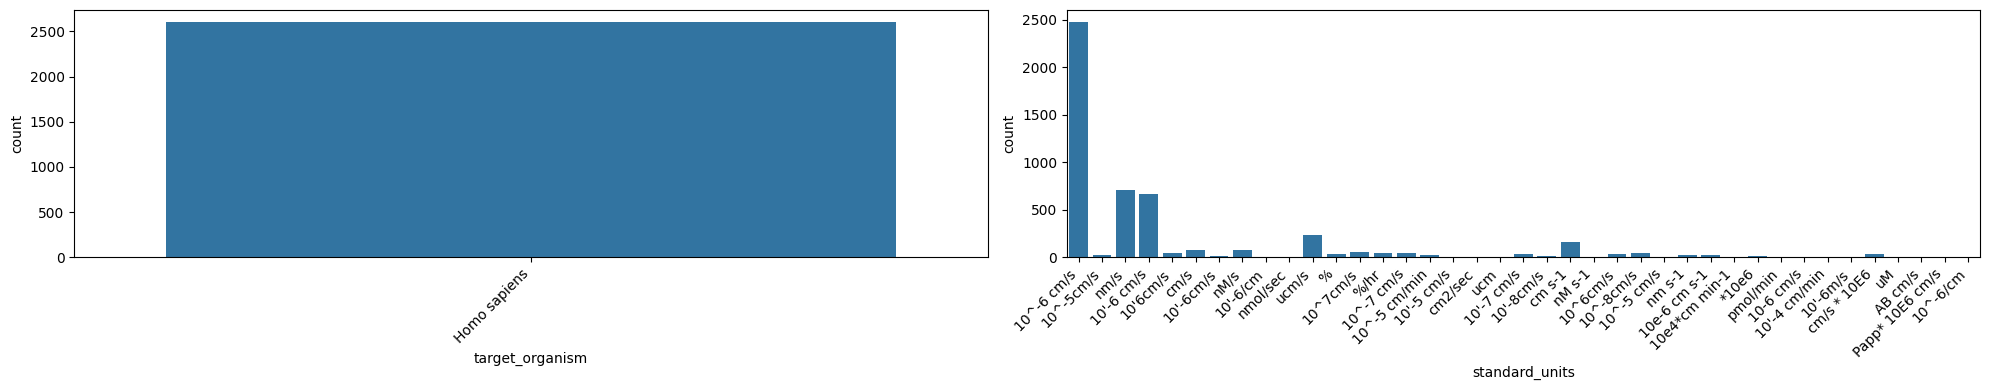

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["target_organism", "standard_units"]
f, axs = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axs, cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels

f.tight_layout()

Keep only those with nM units and non-zero.

In [29]:
counts = df['standard_units'].value_counts()

print(counts)

standard_units
10^-6 cm/s         2478
nm/s                709
10'-6 cm/s          661
ucm/s               231
cm s-1              160
cm/s                 77
nM/s                 75
10^7cm/s             50
%/hr                 46
10^-7 cm/s           43
10^-8cm/s            41
10'6cm/s             40
10^6cm/s             39
10'-7 cm/s           39
%                    39
cm/s * 10E6          30
10^-5cm/s            23
10e-6 cm s-1         23
10^-5 cm/min         21
nm s-1               19
10'-8cm/s            16
10'-6cm/s            11
*10e6                 8
10^-5 cm/s            7
ucm                   6
10'-4 cm/min          6
Papp* 10E6 cm/s       6
nM s-1                4
10e4*cm min-1         4
AB cm/s               4
nmol/sec              3
10'-5 cm/s            3
10^-6/cm              2
10'-6/cm              1
cm2/sec               1
pmol/min              1
10-6 cm/s             1
10'-6m/s              1
uM                    1
Name: count, dtype: int64


In [31]:
filtered_df = df[
    (df['standard_units'] == "10^-6 cm/s") | 
    (df['standard_units'] == "10'-6 cm/s") |
    (df['standard_units'] == "10'6cm/s") |
    (df['standard_units'] == "10^6cm/s") |
    (df['standard_units'] == "10e-6 cm s-1") |
    (df['standard_units'] == "10'-6cm/s") |
    (df['standard_units'] == "10^-6/cm") |
    (df['standard_units'] == "10^-6/cm") |
    (df['standard_units'] == "10'-6/cm") |
    (df['standard_units'] == "10-6 cm/s") |
    (df['standard_units'] == "10'-6m/s")    
    ]
filtered_df = filtered_df[filtered_df['standard_value'] != 0]
len(filtered_df)

3221

Data is clearly unbalanced will need to sample.

<Axes: xlabel='standard_value', ylabel='Count'>

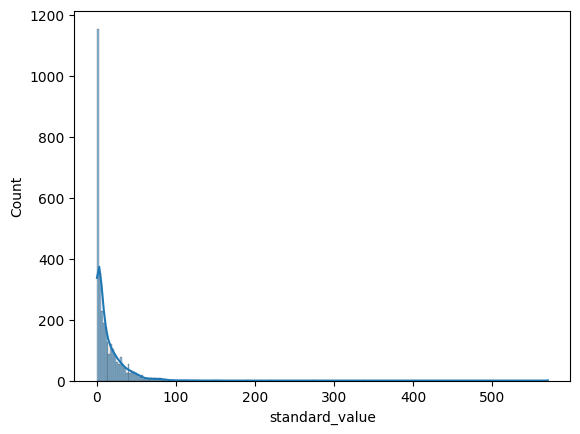

In [32]:
sns.histplot(data=filtered_df, x="standard_value", kde=True)

In [34]:
# Dump to file.

filtered_df.to_csv(DATA / f"{readout}_chembl.csv")